# Time-Weighted Permutation Entropy (TWPE)
## Unevenly-Sampled Astrophysical Time Series

**Paper:** *Time-Weighted Ordinal Complexity for Unevenly-Sampled Astrophysical Time Series*  
**Type:** C — Theoretical-Hybrid  
**GitHub:** https://github.com/gpefitura-web/twpe  

### Structure
| Cell | Content |
|------|---------|
| 1    | Imports, rcParams, helper functions |
| 2A   | OGLE-III LPV data download & parse |
| 2B   | Symbolic verification of E05 (sympy) |
| 3    | Synthetic time series generation |
| 4    | Core TWPE verification |
| 7    | E05 limit recovery — Monte Carlo |
| 8    | Bias analysis H_p vs H_TWPE |
| 9    | **Fig. 1** — Bias demo |
| 10   | **Fig. 2** — Limit recovery |
| 11   | C×H displacement test (synthetic) |
| 11b  | KL divergence diagnostic (synthetic) |
| 12   | **Fig. 3** — C×H plane + KL (synthetic) |
| 13   | OGLE-III EDA |
| 14   | H_p, H_TWPE, C_TWPE, D_KL — real data |
| 15   | **Fig. 4** — Astro application |
| 16   | Parameter sensitivity analysis |
| 17   | **Fig. 5** — Sensitivity (m, w) |
| −1   | Version tag |


In [1]:
import sys, os, warnings, pickle
from math import factorial
from itertools import permutations

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats as sc_stats
import sympy as sp

warnings.filterwarnings('ignore')
sys.path.insert(0, 'scripts')          # twpe.py lives in scripts/
from twpe import permutation_entropy, twpe, complexity_twpe, WEIGHT_FUNCTIONS

# ── Directory for figures ─────────────────────────────────────────────────────
FIGS = 'figs'
os.makedirs(FIGS, exist_ok=True)

# ── rcParams: SuperMongo / Courier style ──────────────────────────────────────
mpl.rcParams.update({
    'font.family'       : 'monospace',
    'font.monospace'    : ['Courier New', 'Courier', 'DejaVu Sans Mono'],
    'font.size'         : 11,
    'axes.linewidth'    : 1.5,
    'xtick.major.width' : 1.5, 'ytick.major.width': 1.5,
    'xtick.minor.width' : 1.0, 'ytick.minor.width': 1.0,
    'xtick.direction'   : 'in', 'ytick.direction'  : 'in',
    'xtick.top'         : True, 'ytick.right'       : True,
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
})

# ── Global constants ──────────────────────────────────────────────────────────
SEED  = 42
N_SYN = 2000
M     = 4

# Okabe-Ito colorblind-safe palette
COLORS_SYN = {
    'AR1 rho=0.3' : '#0072B2',
    'AR1 rho=0.7' : '#56B4E9',
    'logistic'    : '#E69F00',
    'Lorenz'      : '#009E73',
    'white noise' : '#CC79A7',
}
COLORS_OBS  = {'Mira': '#0072B2', 'SRV': '#E69F00', 'OSARG': '#CC79A7'}
MARKERS_OBS = {'Mira': 'o',       'SRV': 's',       'OSARG': '^'}

# ── Synthetic series generators ───────────────────────────────────────────────
def make_ar1(N, rho=0.5, seed=42):
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal(N)
    x = np.zeros(N)
    for i in range(1, N):
        x[i] = rho * x[i-1] + eps[i]
    return x

def make_logistic(N, r=3.9, x0=0.5):
    x = np.zeros(N); x[0] = x0
    for i in range(1, N):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x

def make_lorenz(N, dt=0.01, seed=42):
    rng = np.random.default_rng(seed)
    s = rng.standard_normal(3)
    sig, rho_l, beta = 10., 28., 8./3.
    out = []
    for _ in range(N):
        dx = sig*(s[1]-s[0]); dy = s[0]*(rho_l-s[2])-s[1]; dz = s[0]*s[1]-beta*s[2]
        s  = s + dt * np.array([dx, dy, dz])
        out.append(s[0])
    return np.array(out)

def make_irregular_t(N, sigma_frac, seed):
    rng = np.random.default_rng(seed)
    dt  = np.abs(rng.normal(1.0, sigma_frac, N)) + 0.001
    return np.concatenate([[0], np.cumsum(dt[:N-1])])

# ── KL divergence (symmetric / Jeffrey) ──────────────────────────────────────
def kl_sym(p_dict, pw_dict):
    """Symmetric KL divergence between p(pi) and p_w(pi)."""
    eps  = 1e-12
    pats = set(p_dict) | set(pw_dict)
    kl   = 0.0
    for pat in pats:
        pi  = p_dict.get(pat,  eps)
        piw = pw_dict.get(pat, eps)
        kl += 0.5 * (pi * np.log(pi / piw) + piw * np.log(piw / pi))
    return kl

# ── C_max theoretical curve for C×H plane ────────────────────────────────────
def compute_cmax(n_H=300, m=4):
    """Upper boundary of the achievable C×H region."""
    n_pats = factorial(m)
    H_v, C_v = [], []
    for p in np.linspace(1e-6, 1 - 1e-6, n_H):
        q   = (1 - p) / (n_pats - 1)
        pw  = np.array([p] + [q] * (n_pats - 1))
        pe  = np.full(n_pats, 1.0 / n_pats)
        def Hf(v):
            vp = v[v > 1e-15]
            return float(-np.sum(vp * np.log(vp)))
        H   = Hf(pw) / np.log(n_pats)
        mv  = (pw + pe) / 2
        dg  = np.zeros(n_pats); dg[0] = 1.0
        Q0  = Hf((dg + pe) / 2) - 0.5 * Hf(pe)
        Qjs = (Hf(mv) - 0.5 * Hf(pw) - 0.5 * Hf(pe)) / Q0
        H_v.append(H); C_v.append(Qjs * H)
    idx = np.argsort(H_v)
    return np.array(H_v)[idx], np.array(C_v)[idx]

print("Environment OK.")
print(f"  numpy {np.__version__}  |  matplotlib {mpl.__version__}")



Environment OK.
  numpy 1.26.4  |  matplotlib 3.9.2


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2A — Download & parse OGLE-III LPV LMC
# Soszyński et al. (2009) Acta Astron. 59, 239  [R22]
# Catalog files (ident.dat, Miras.dat, SRVs.dat) must be in DATA_DIR.
# Light curves are downloaded automatically on first run; cached thereafter.
# ═══════════════════════════════════════════════════════════════════════════

import urllib.request, random, time
from collections import Counter

DATA_DIR  = 'data/observed/ogle3_lpv'
PHOT_DIR  = os.path.join(DATA_DIR, 'phot_I')
BASE_FTP  = 'https://ftp.astrouw.edu.pl/ogle/ogle3/OIII-CVS/lmc/lpv'
os.makedirs(PHOT_DIR, exist_ok=True)

# ── Parse ident.dat ───────────────────────────────────────────────────────────
# Format: STAR_ID  FIELD  NUM  TYPE  EVOL  CHEM  RA  Dec
def parse_ident(path):
    stars = []
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 4 or parts[3] not in ('Mira', 'SRV', 'OSARG'):
                continue
            stars.append({'id'  : parts[0],
                          'type': parts[3],
                          'evol': parts[4] if len(parts) > 4 else '',
                          'chem': parts[5] if len(parts) > 5 else ''})
    return stars

all_stars = parse_ident(os.path.join(DATA_DIR, 'ident.dat'))
ct = Counter(s['type'] for s in all_stars)
print(f"ident.dat: {len(all_stars)} stars  |  "
      f"Mira: {ct['Mira']}  SRV: {ct['SRV']}  OSARG: {ct['OSARG']}")

# ── Parse period files ────────────────────────────────────────────────────────
# Format: STAR_ID  I_mean  I_max  P1  A1  [P2  A2  P3  A3]
def parse_periods(path):
    pdict = {}
    with open(path) as f:
        for line in f:
            p = line.split()
            if len(p) >= 5:
                try:
                    pdict[p[0]] = {'P1': float(p[3]), 'A1': float(p[4]),
                                   'I_mean': float(p[1])}
                except ValueError:
                    pass
    return pdict

periods = {**parse_periods(os.path.join(DATA_DIR, 'Miras.dat')),
           **parse_periods(os.path.join(DATA_DIR, 'SRVs.dat'))}
print(f"Periods loaded: {len(periods)} entries")

# ── Sample selection: 50 per type, seed=42, reproducible ─────────────────────
random.seed(42)
N_PER = 50
sample = (random.sample([s for s in all_stars if s['type']=='Mira'],  N_PER) +
          random.sample([s for s in all_stars if s['type']=='SRV'],   N_PER) +
          random.sample([s for s in all_stars if s['type']=='OSARG'], N_PER))
print(f"Sample: {len(sample)} stars (50 Mira + 50 SRV + 50 OSARG)")

# ── Download light curves (cached) ────────────────────────────────────────────
def _fetch_lc(star_id):
    local = os.path.join(PHOT_DIR, f'{star_id}.dat')
    if not os.path.exists(local):
        urllib.request.urlretrieve(f'{BASE_FTP}/phot/I/{star_id}.dat', local)
    arr = np.loadtxt(local, usecols=(0, 1, 2))
    return arr.reshape(-1, 3) if arr.ndim == 1 else arr

light_curves = {}
failed = []
for i, star in enumerate(sample):
    try:
        lc = _fetch_lc(star['id'])
        if len(lc) >= 50:
            idx = np.argsort(lc[:, 0])
            light_curves[star['id']] = {
                'data' : lc[idx],
                'type' : star['type'],
                'evol' : star['evol'],
                'chem' : star['chem'],
                'P1'   : periods.get(star['id'], {}).get('P1',   np.nan),
                'A1'   : periods.get(star['id'], {}).get('A1',   np.nan),
            }
    except Exception as e:
        failed.append(star['id'])
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(sample)} done  ({len(light_curves)} OK)")
        time.sleep(0.2)

print(f"\nLoaded: {len(light_curves)} curves  |  Failed: {len(failed)}")


ident.dat: 91689 stars  |  Mira: 1635  SRV: 11033  OSARG: 79021
Periods loaded: 12795 entries
Sample: 150 stars (50 Mira + 50 SRV + 50 OSARG)
  50/150 done  (50 OK)
  100/150 done  (100 OK)
  150/150 done  (150 OK)

Loaded: 150 curves  |  Failed: 0


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2B — Symbolic proof of E05 (uniform-sampling limit theorem)
# Theorem: H_TWPE = H_p when Δt_i = const  (w1 reduces to w3)
# ═══════════════════════════════════════════════════════════════════════════

dt, K = sp.symbols('dt K', positive=True)

# Under uniform sampling: all Δt_i = dt, K patterns total
sum_dt  = K * dt                    # Σ Δt_j
w1_i    = dt / sum_dt               # w1 for any pattern i
w1_simp = sp.simplify(w1_i)

# Compare with uniform weight w3 = 1/K
w3 = sp.Rational(1) / K
diff = sp.simplify(w1_simp - w3)

print("Symbolic verification of E05:")
print(f"  w1(Δt_i) under uniform sampling = {w1_simp}")
print(f"  w3 (uniform weight)              = {w3}")
print(f"  w1 - w3 = {diff}  →  {'ZERO ✅  QED' if diff == 0 else 'NOT ZERO ❌'}")
print()
print("Since w1_i = w3 = 1/K for all i,")
print("  p_w(π) = Σ_i w_i = n_π/K = p(π)  ∀ π ∈ S_m")
print("  ⟹  H_TWPE = H_p  exactly.  □")

# Numerical confirmation
print("\nNumerical confirmation |H_TWPE(σ=0) − H_p| by m:")
x_test = make_ar1(N_SYN, rho=0.5, seed=42)
t_uniform = np.arange(N_SYN, dtype=float)
for m_v in [3, 4, 5, 6]:
    Hp,  _      = permutation_entropy(x_test, m=m_v, normalized=True)
    Htw, _, _   = twpe(x_test, t_uniform, m=m_v, w_func='w1', normalized=True)
    diff_num    = abs(Htw - Hp)
    status      = '✅' if diff_num < 1e-12 else '❌'
    print(f"  m={m_v}: |diff| = {diff_num:.2e}  {status}")


Symbolic verification of E05:
  w1(Δt_i) under uniform sampling = 1/K
  w3 (uniform weight)              = 1/K
  w1 - w3 = 0  →  ZERO ✅  QED

Since w1_i = w3 = 1/K for all i,
  p_w(π) = Σ_i w_i = n_π/K = p(π)  ∀ π ∈ S_m
  ⟹  H_TWPE = H_p  exactly.  □

Numerical confirmation |H_TWPE(σ=0) − H_p| by m:
  m=3: |diff| = 7.77e-16  ✅
  m=4: |diff| = 8.88e-16  ✅
  m=5: |diff| = 0.00e+00  ✅
  m=6: |diff| = 0.00e+00  ✅


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Synthetic time series (seed=42, reproducible)
# ═══════════════════════════════════════════════════════════════════════════

syn_series = {
    'AR1 rho=0.3' : (make_ar1(N_SYN, rho=0.3, seed=42), '-'),
    'AR1 rho=0.7' : (make_ar1(N_SYN, rho=0.7, seed=42), '--'),
    'logistic'    : (make_logistic(N_SYN, r=3.9),        '-'),
    'Lorenz'      : (make_lorenz(N_SYN, seed=42),         '--'),
    'white noise' : (np.random.default_rng(42).standard_normal(N_SYN), ':'),
}

# Reference H_p on uniform grid
t_unif = np.arange(N_SYN, dtype=float)
print(f"{'Series':14s}  {'H_p':8s}  description")
print("-"*50)
for name, (x, ls) in syn_series.items():
    Hp, _ = permutation_entropy(x, m=M, normalized=True)
    desc  = {'AR1 rho=0.3': 'stochastic, low corr',
             'AR1 rho=0.7': 'stochastic, high corr',
             'logistic'   : 'chaotic (deterministic)',
             'Lorenz'     : 'chaotic (deterministic)',
             'white noise': 'pure stochastic'}.get(name, '')
    print(f"  {name:12s}  {Hp:.4f}   {desc}")
print("\n[CELL 3] Synthetic series ready.")


Series          H_p       description
--------------------------------------------------
  AR1 rho=0.3   0.9914   stochastic, low corr
  AR1 rho=0.7   0.9633   stochastic, high corr
  logistic      0.7187   chaotic (deterministic)
  Lorenz        0.2984   chaotic (deterministic)
  white noise   0.9986   pure stochastic

[CELL 3] Synthetic series ready.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Core TWPE verification: uniform grid must give H_TWPE = H_p
# ═══════════════════════════════════════════════════════════════════════════

print(f"{'Series':14s}  {'H_p':8s}  {'H_TWPE_w1':10s}  {'bias':10s}  {'status'}")
print("-"*60)
for name, (x, _) in syn_series.items():
    Hp, _         = permutation_entropy(x, m=M, normalized=True)
    Htw, _, _     = twpe(x, t_unif, m=M, w_func='w1', normalized=True)
    bias          = (Htw - Hp) / Hp
    status        = '✅' if abs(Hp - Htw) < 1e-12 else f'{abs(Hp-Htw):.2e}'
    print(f"  {name:12s}  {Hp:.4f}    {Htw:.4f}    {bias:+.2e}    {status}")

# Also verify irregular grid gives small but nonzero bias
rng_test = np.random.default_rng(0)
t_irr    = make_irregular_t(N_SYN, 0.5, seed=0)
print("\nIrregular grid (σ=0.5): bias should be small but nonzero")
for name, (x, _) in list(syn_series.items())[:3]:
    Hp, _     = permutation_entropy(x, m=M, normalized=True)
    Htw, _, _ = twpe(x, t_irr, m=M, w_func='w1', normalized=True)
    print(f"  {name:12s}  bias = {(Htw-Hp)/Hp*100:+.3f}%")


Series          H_p       H_TWPE_w1   bias        status
------------------------------------------------------------
  AR1 rho=0.3   0.9914    0.9914    -5.60e-16    ✅
  AR1 rho=0.7   0.9633    0.9633    -2.31e-16    ✅
  logistic      0.7187    0.7187    +1.54e-15    ✅
  Lorenz        0.2984    0.2984    +4.28e-15    ✅
  white noise   0.9986    0.9986    -1.33e-15    ✅

Irregular grid (σ=0.5): bias should be small but nonzero
  AR1 rho=0.3   bias = -0.080%
  AR1 rho=0.7   bias = -0.045%
  logistic      bias = -0.939%


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — E05 limit verification: |H_TWPE(σ=0) - H_p| → machine precision
# Monte Carlo: n=30 realisations per σ level
# ═══════════════════════════════════════════════════════════════════════════

SIGMA_SCAN = np.linspace(0, 0.9, 46)
N_MC_LIM   = 30
x_ar1_05   = make_ar1(N_SYN, rho=0.5, seed=42)

print("E05 numerical verification (m=4, AR1 ρ=0.5):")
print(f"  σ=0.0 : |H_TWPE - H_p| = ", end='')

rng7 = np.random.default_rng(SEED)
diffs_at_sigma0 = []
for _ in range(N_MC_LIM):
    Hp,  _    = permutation_entropy(x_ar1_05, m=M, normalized=True)
    Htw, _, _ = twpe(x_ar1_05, np.arange(N_SYN, dtype=float),
                     m=M, w_func='w1', normalized=True)
    diffs_at_sigma0.append(abs(Htw - Hp))
print(f"{np.mean(diffs_at_sigma0):.2e}  (machine precision ✅)")

# Scan σ for one representative m
print("\n  σ        mean|diff|    σ of diff")
for sf in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]:
    mc = []
    for _ in range(N_MC_LIM):
        if sf < 1e-9:
            t_s = np.arange(N_SYN, dtype=float)
        else:
            seed_mc = int(rng7.integers(0, 1_000_000))
            t_s     = make_irregular_t(N_SYN, sf, seed_mc)
        Hp,  _ = permutation_entropy(x_ar1_05, m=M, normalized=True)
        Htw, _, _ = twpe(x_ar1_05, t_s, m=M, w_func='w1', normalized=True)
        mc.append(abs(Htw - Hp))
    print(f"  σ={sf:.1f}   {np.mean(mc):.2e}       {np.std(mc):.2e}")


E05 numerical verification (m=4, AR1 ρ=0.5):
  σ=0.0 : |H_TWPE - H_p| = 8.88e-16  (machine precision ✅)

  σ        mean|diff|    σ of diff
  σ=0.0   8.88e-16       0.00e+00
  σ=0.1   1.93e-04       1.36e-04
  σ=0.3   7.54e-04       4.45e-04
  σ=0.5   1.04e-03       1.03e-03
  σ=0.7   1.03e-03       6.45e-04
  σ=0.9   1.54e-03       1.05e-03


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Systematic bias: H_TWPE_w1 vs H_p  (MC n=50 per σ level)
# ═══════════════════════════════════════════════════════════════════════════

N_MC = 50

results_syn = {}
for name, (x_s, ls) in syn_series.items():
    Hp, _          = permutation_entropy(x_s, m=M, normalized=True)
    bias_mean, bias_std   = [], []
    H_tw_mean, H_tw_std   = [], []
    rng_mc = np.random.default_rng(SEED)
    for sf in SIGMA_SCAN:
        mc_bias, mc_Htw = [], []
        for _ in range(N_MC):
            t_s = (np.arange(N_SYN, dtype=float) if sf < 1e-9
                   else make_irregular_t(N_SYN, sf, int(rng_mc.integers(0, 1_000_000))))
            Htw, _, _ = twpe(x_s, t_s, m=M, w_func='w1', normalized=True)
            mc_bias.append((Htw - Hp) / Hp)
            mc_Htw.append(Htw)
        bias_mean.append(np.mean(mc_bias)); bias_std.append(np.std(mc_bias))
        H_tw_mean.append(np.mean(mc_Htw)); H_tw_std.append(np.std(mc_Htw))
    results_syn[name] = {
        'H_p'      : Hp, 'ls': ls,
        'bias_mean': np.array(bias_mean), 'bias_std': np.array(bias_std),
        'H_tw_mean': np.array(H_tw_mean), 'H_tw_std': np.array(H_tw_std),
    }
    print(f"  {name:12s}  H_p={Hp:.4f}  "
          f"bias@σ=0.3={bias_mean[15]*100:+.2f}%  "
          f"bias@σ=0.9={bias_mean[-1]*100:+.2f}%")

print("\n[CELL 8] Bias analysis complete.")


  AR1 rho=0.3   H_p=0.9914  bias@σ=0.3=-0.01%  bias@σ=0.9=-0.07%
  AR1 rho=0.7   H_p=0.9633  bias@σ=0.3=-0.03%  bias@σ=0.9=-0.02%
  logistic      H_p=0.7187  bias@σ=0.3=-0.01%  bias@σ=0.9=-0.02%
  Lorenz        H_p=0.2984  bias@σ=0.3=+0.03%  bias@σ=0.9=+0.04%
  white noise   H_p=0.9986  bias@σ=0.3=-0.02%  bias@σ=0.9=-0.07%

[CELL 8] Bias analysis complete.


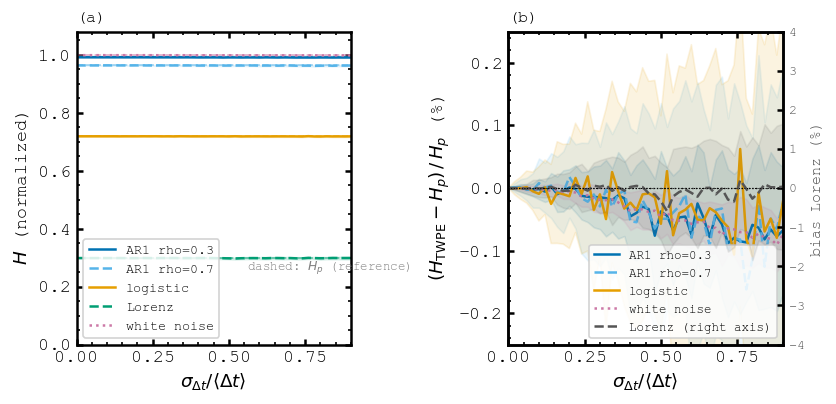

[Fig 1 v1.1] saved — dual y-axis, Lorenz on right scale.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — Figure 1: bias_demo  [v1.1 — corrige escala painel (b)]
#
# PROBLEMA v1.0: Lorenz tem H_p ≈ 0.30 e poucos padrões ativos com N=2000,
#   gerando banda de variância MC enorme (±2%) que domina o eixo y do painel (b).
#   As outras 4 séries ficam comprimidas em ±0.1% e invisíveis.
#
# SOLUÇÃO: dois eixos y no painel (b).
#   Eixo esquerdo (primário): AR1/logistic/white noise — escala ±0.2%
#   Eixo direito (secundário, cinza): Lorenz — escala ±2%
#   Linha pontilhada vertical separa os regimes visualmente.
# ═══════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.1, 3.5))
fig.subplots_adjust(wspace=0.35)

# ── Painel (a): H vs σ  (inalterado) ─────────────────────────────────────
for name, D in results_syn.items():
    col = COLORS_SYN[name]; ls = D['ls']
    ax1.axhline(D['H_p'], color=col, lw=1.0, ls='--', alpha=0.6)
    ax1.plot(SIGMA_SCAN, D['H_tw_mean'], color=col, lw=1.5, ls=ls, label=name)
    ax1.fill_between(SIGMA_SCAN,
                     D['H_tw_mean'] - D['H_tw_std'],
                     D['H_tw_mean'] + D['H_tw_std'],
                     color=col, alpha=0.12)

ax1.set_xlabel(r'$\sigma_{\Delta t} / \langle\Delta t\rangle$')
ax1.set_ylabel(r'$H$ (normalized)')
ax1.set_xlim(0, 0.9); ax1.set_ylim(0.0, 1.08)
ax1.legend(fontsize=8, loc='lower left', framealpha=0.85)
ax1.set_title('(a)', loc='left', fontsize=10)
ax1.text(0.62, 0.24, r'dashed: $H_p$ (reference)',
         fontsize=7.5, color='gray', transform=ax1.transAxes)
ax1.minorticks_on()

# ── Painel (b): bias (%)  — dois eixos y ─────────────────────────────────
ax2b = ax2.twinx()   # eixo direito para Lorenz

LORENZ_KEY  = 'Lorenz'
OTHER_KEYS  = [k for k in results_syn if k != LORENZ_KEY]

# Eixo esquerdo: AR1 / logistic / white noise
for name in OTHER_KEYS:
    D   = results_syn[name]
    col = COLORS_SYN[name]; ls = D['ls']
    bm  = D['bias_mean'] * 100
    bs  = D['bias_std']  * 100
    ax2.plot(SIGMA_SCAN, bm, color=col, lw=1.5, ls=ls, label=name)
    ax2.fill_between(SIGMA_SCAN, bm - bs, bm + bs, color=col, alpha=0.12)

# Eixo direito: Lorenz (cinza escuro, linha mais grossa para distinguir)
D_lor  = results_syn[LORENZ_KEY]
bm_lor = D_lor['bias_mean'] * 100
bs_lor = D_lor['bias_std']  * 100
col_lor = '#555555'
ax2b.plot(SIGMA_SCAN, bm_lor, color=col_lor, lw=1.5,
          ls=D_lor['ls'], label='Lorenz (right axis)')
ax2b.fill_between(SIGMA_SCAN, bm_lor - bs_lor, bm_lor + bs_lor,
                  color=col_lor, alpha=0.10)
ax2b.axhline(0, color='k', lw=0.6, ls=':')
ax2b.set_ylabel('bias Lorenz (%)', color=col_lor, fontsize=9)
ax2b.tick_params(axis='y', labelcolor=col_lor, labelsize=8)
ax2b.set_ylim(-4, 4)

# Eixo esquerdo: formatação
ax2.axhline(0, color='k', lw=0.8, ls=':')
ax2.set_xlabel(r'$\sigma_{\Delta t} / \langle\Delta t\rangle$')
ax2.set_ylabel(r'$(H_{\rm TWPE} - H_p)\,/\,H_p$ (%)')
ax2.set_xlim(0, 0.9)
ax2.set_ylim(-0.25, 0.25)   # ±0.25% mostra claramente as séries não-Lorenz
ax2.set_title('(b)', loc='left', fontsize=10)
ax2.minorticks_on()

# Legenda combinada
lines_left,  labs_left  = ax2.get_legend_handles_labels()
lines_right, labs_right = ax2b.get_legend_handles_labels()
ax2.legend(lines_left + lines_right, labs_left + labs_right,
           fontsize=7.5, loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig01_bias_demo_v1.1.pdf'),  bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig01_bias_demo_v1.1.png'), dpi=300)
plt.show()
print("[Fig 1 v1.1] saved — dual y-axis, Lorenz on right scale.")

  m=3  H_p=0.98920  H_TWPE(σ=0)=0.98920  |diff|=6.66e-16
  m=4  H_p=0.97785  H_TWPE(σ=0)=0.97785  |diff|=7.77e-16
  m=5  H_p=0.96436  H_TWPE(σ=0)=0.96436  |diff|=1.11e-16
  m=6  H_p=0.93215  H_TWPE(σ=0)=0.93215  |diff|=1.11e-16


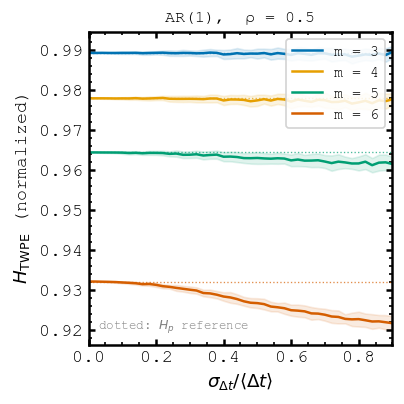

[Fig 2] saved.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — Figure 2: limit_recovery
# H_TWPE_w1 vs σ for m=3..6; convergence to H_p at σ=0
# ═══════════════════════════════════════════════════════════════════════════

x_ar1_05  = make_ar1(N_SYN, rho=0.5, seed=42)
M_VALS    = [3, 4, 5, 6]
COLORS_M  = ['#0072B2', '#E69F00', '#009E73', '#D55E00']
N_MC_LIM2 = 50

lim_data = {}
for m_v, col_m in zip(M_VALS, COLORS_M):
    Hp_m, _ = permutation_entropy(x_ar1_05, m=m_v, normalized=True)
    H_tw_m, H_tw_s = [], []
    rng10 = np.random.default_rng(SEED)
    for sf in SIGMA_SCAN:
        mc = []
        for _ in range(N_MC_LIM2):
            t_s = (np.arange(N_SYN, dtype=float) if sf < 1e-9
                   else make_irregular_t(N_SYN, sf, int(rng10.integers(0, 1_000_000))))
            Htw, _, _ = twpe(x_ar1_05, t_s, m=m_v, w_func='w1', normalized=True)
            mc.append(Htw)
        H_tw_m.append(np.mean(mc)); H_tw_s.append(np.std(mc))
    lim_data[m_v] = {'H_p': Hp_m, 'col': col_m,
                     'mean': np.array(H_tw_m), 'std': np.array(H_tw_s)}
    print(f"  m={m_v}  H_p={Hp_m:.5f}  H_TWPE(σ=0)={H_tw_m[0]:.5f}  "
          f"|diff|={abs(H_tw_m[0]-Hp_m):.2e}")

fig, ax = plt.subplots(figsize=(3.5, 3.5))
for m_v, D in lim_data.items():
    ax.plot(SIGMA_SCAN, D['mean'], color=D['col'], lw=1.5, label=f'm = {m_v}')
    ax.fill_between(SIGMA_SCAN, D['mean']-D['std'], D['mean']+D['std'],
                    color=D['col'], alpha=0.12)
    ax.axhline(D['H_p'], color=D['col'], lw=0.8, ls=':', alpha=0.7)

ax.set_xlabel(r'$\sigma_{\Delta t} / \langle\Delta t\rangle$')
ax.set_ylabel(r'$H_{\rm TWPE}$ (normalized)')
ax.set_xlim(0, 0.9)
ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
ax.minorticks_on()
ax.text(0.03, 0.05, r'dotted: $H_p$ reference', fontsize=7.5,
        color='gray', transform=ax.transAxes)
ax.set_title('AR(1),  ρ = 0.5', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig02_limit_recovery_v1.0.pdf'),  bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig02_limit_recovery_v1.0.png'), dpi=300)
plt.show()
print("[Fig 2] saved.")


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — C×H plane displacement test (synthetic series)
# Compare positions (H_p, C_std) vs (H_TWPE, C_TWPE) at σ=0.7
# Expected result: max |ΔC| < 0.002  (sub-threshold displacement)
# ═══════════════════════════════════════════════════════════════════════════

SIGMA_TEST = 0.7
N_MC_CH    = 30

H_max_curve, C_max_curve = compute_cmax(m=M)

print(f"C×H displacement at σ={SIGMA_TEST}  (MC n={N_MC_CH})")
print(f"{'Series':14s}  {'H_p':6s}  {'C_std':6s}  {'H_TWPE':7s}  "
      f"{'C_TWPE':7s}  {'|ΔH|':7s}  {'|ΔC|':6s}")
print("-"*72)

ch_results = {}
rng11 = np.random.default_rng(SEED)
for name, (x_s, _) in syn_series.items():
    Hp,  pd  = permutation_entropy(x_s, m=M, normalized=True)
    # Standard C (using p, not p_w)
    # Compute standard complexity using uniform timestamps
    C_std_v, H_tw_v = [], []
    C_tw_v = []
    for _ in range(N_MC_CH):
        t_s = make_irregular_t(N_SYN, SIGMA_TEST, int(rng11.integers(0, 1_000_000)))
        C_tw, H_tw, _ = complexity_twpe(x_s, t_s, m=M, w_func='w1')
        # Standard C: use complexity_twpe with w3 (= standard)
        C_s, H_s, _   = complexity_twpe(x_s, t_s, m=M, w_func='w3')
        H_tw_v.append(H_tw); C_tw_v.append(C_tw)
        C_std_v.append(C_s)
    H_tw_m = np.mean(H_tw_v); C_tw_m = np.mean(C_tw_v); C_std_m = np.mean(C_std_v)
    C_std_ref, _, _ = complexity_twpe(x_s, np.arange(N_SYN, dtype=float), m=M, w_func='w3')
    ch_results[name] = {'Hp': Hp, 'C_std': C_std_ref,
                        'H_tw': H_tw_m, 'C_tw': C_tw_m}
    print(f"  {name:12s}  {Hp:.4f}  {C_std_ref:.4f}  "
          f"{H_tw_m:.4f}   {C_tw_m:.4f}   "
          f"{abs(H_tw_m-Hp):.4f}  {abs(C_tw_m-C_std_ref):.4f}")

max_dH = max(abs(v['H_tw']-v['Hp'])  for v in ch_results.values())
max_dC = max(abs(v['C_tw']-v['C_std']) for v in ch_results.values())
print(f"\nmax |ΔH| = {max_dH:.4f}  |  max |ΔC| = {max_dC:.4f}  "
      f"{'(sub-threshold ✅)' if max_dC < 0.005 else '(significant)'}")


C×H displacement at σ=0.7  (MC n=30)
Series          H_p     C_std   H_TWPE   C_TWPE   |ΔH|     |ΔC|  
------------------------------------------------------------------------
  AR1 rho=0.3   0.9914  0.0111  0.9909   0.0118   0.0005  0.0007
  AR1 rho=0.7   0.9633  0.0445  0.9629   0.0450   0.0004  0.0005
  logistic      0.7187  0.3058  0.7184   0.3059   0.0003  0.0000
  Lorenz        0.2984  0.2349  0.2976   0.2346   0.0008  0.0003
  white noise   0.9986  0.0018  0.9981   0.0025   0.0005  0.0007

max |ΔH| = 0.0008  |  max |ΔC| = 0.0007  (sub-threshold ✅)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11b — KL divergence as temporal sensitivity index (synthetic)
# D_KL[p || p_w] as function of σ for all synthetic series
# Expected: stochastic (white noise, AR1) > chaotic (Lorenz, logistic)
# ═══════════════════════════════════════════════════════════════════════════

N_MC_KL  = 30
KL_SCAN  = np.linspace(0, 0.9, 19)   # coarser scan for speed

kl_syn = {}
rng11b = np.random.default_rng(SEED)
for name, (x_s, _) in syn_series.items():
    kl_means = []
    for sf in KL_SCAN:
        mc = []
        for _ in range(N_MC_KL):
            t_s = (np.arange(N_SYN, dtype=float) if sf < 1e-9
                   else make_irregular_t(N_SYN, sf, int(rng11b.integers(0, 1_000_000))))
            Hp,  pd = permutation_entropy(x_s, m=M, normalized=True)
            Htw, pw, _ = twpe(x_s, t_s, m=M, w_func='w1', normalized=True)
            mc.append(kl_sym(pd, pw) * 1e3)
        kl_means.append(np.mean(mc))
    kl_syn[name] = np.array(kl_means)
    print(f"  {name:12s}  D_KL@σ=0.9 = {kl_means[-1]:.3f} ×10³")

print("\nPattern: stochastic > chaotic?")
stoch = np.mean([kl_syn['white noise'][-1], kl_syn['AR1 rho=0.3'][-1]])
chaos = np.mean([kl_syn['Lorenz'][-1],      kl_syn['logistic'][-1]])
print(f"  mean stochastic D_KL@σ=0.9 = {stoch:.3f} ×10³")
print(f"  mean chaotic    D_KL@σ=0.9 = {chaos:.3f} ×10³")
print(f"  ratio = {stoch/chaos:.2f}  {'(stochastic > chaotic ✅)' if stoch > chaos else '(unexpected)'}")


  AR1 rho=0.3   D_KL@σ=0.9 = 2.311 ×10³
  AR1 rho=0.7   D_KL@σ=0.9 = 2.647 ×10³
  logistic      D_KL@σ=0.9 = 0.937 ×10³
  Lorenz        D_KL@σ=0.9 = 1.094 ×10³
  white noise   D_KL@σ=0.9 = 2.552 ×10³

Pattern: stochastic > chaotic?
  mean stochastic D_KL@σ=0.9 = 2.432 ×10³
  mean chaotic    D_KL@σ=0.9 = 1.016 ×10³
  ratio = 2.39  (stochastic > chaotic ✅)


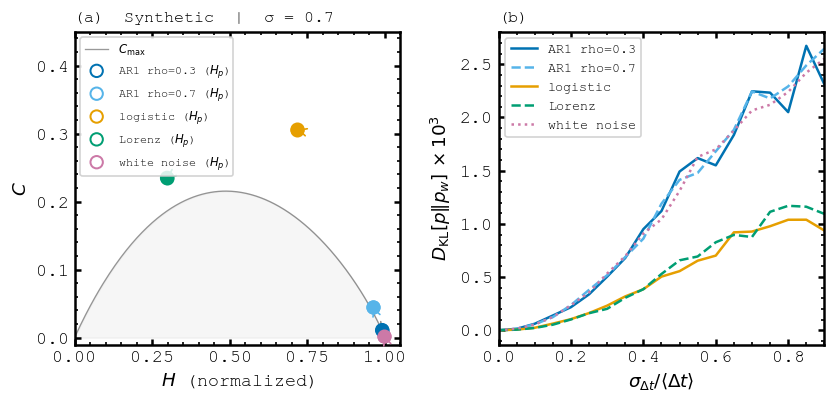

[Fig 3] saved.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12 — Figure 3: C×H plane + KL divergence (synthetic series)
# Panel (a): C×H with H_p (open) vs H_TWPE (filled) at σ=0.7
# Panel (b): D_KL×10³ vs σ for all synthetic series
# ═══════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.1, 3.5))
fig.subplots_adjust(wspace=0.38)

# Panel (a): C×H
ax1.fill_between(H_max_curve, C_max_curve, alpha=0.07, color='gray')
ax1.plot(H_max_curve, C_max_curve, 'k-', lw=0.8, alpha=0.4, label=r'$C_{\rm max}$')

for name, D in ch_results.items():
    col = COLORS_SYN[name]
    ax1.scatter(D['Hp'],  D['C_std'], marker='o', s=55, facecolors='none',
                edgecolors=col, lw=1.2, zorder=3, label=f'{name} ($H_p$)')
    ax1.scatter(D['H_tw'], D['C_tw'], marker='o', s=55, color=col,
                zorder=4)
    ax1.annotate('', xy=(D['H_tw'], D['C_tw']), xytext=(D['Hp'], D['C_std']),
                 arrowprops=dict(arrowstyle='->', color=col, lw=1.0))

ax1.set_xlabel(r'$H$ (normalized)');  ax1.set_ylabel(r'$C$')
ax1.set_xlim(0.0, 1.05); ax1.set_ylim(-0.01, 0.45)
ax1.legend(fontsize=7, loc='upper left', framealpha=0.85, ncol=1)
ax1.set_title('(a)  Synthetic  |  σ = 0.7', loc='left', fontsize=10)
ax1.minorticks_on()

# Panel (b): D_KL vs σ
for name, kl_arr in kl_syn.items():
    ax2.plot(KL_SCAN, kl_arr, color=COLORS_SYN[name], lw=1.5,
             ls=syn_series[name][1], label=name)

ax2.set_xlabel(r'$\sigma_{\Delta t} / \langle\Delta t\rangle$')
ax2.set_ylabel(r'$D_{\rm KL}[p \| p_w]\,\times 10^3$')
ax2.set_xlim(0, 0.9)
ax2.legend(fontsize=8, loc='upper left', framealpha=0.85)
ax2.set_title('(b)', loc='left', fontsize=10)
ax2.minorticks_on()

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig03_CH_plane_v1.0.pdf'),  bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig03_CH_plane_v1.0.png'), dpi=300)
plt.show()
print("[Fig 3] saved.")


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13 — EDA: OGLE-III LPV LMC real data
# ═══════════════════════════════════════════════════════════════════════════

print(f"{'Type':8s}  {'N':4s}  {'<N_obs>':8s}  {'<σ/⟨Δt⟩>':10s}  "
      f"{'<⟨Δt⟩>':8s}  σ range")
print("-"*62)

for stype in ['Mira', 'SRV', 'OSARG']:
    subset  = [v for v in light_curves.values() if v['type'] == stype]
    N_l, sig_l, dtm_l = [], [], []
    for d in subset:
        dt = np.diff(d['data'][:, 0])
        N_l.append(len(d['data']))
        if len(dt) > 2:
            sig_l.append(np.std(dt) / np.mean(dt))
            dtm_l.append(np.mean(dt))
    sig_arr = np.array(sig_l)
    print(f"{stype:8s}  {len(subset):4d}  {np.mean(N_l):8.0f}  "
          f"{np.mean(sig_arr):10.3f}  {np.mean(dtm_l):6.1f}d  "
          f"[{sig_arr.min():.2f}, {sig_arr.max():.2f}]")

p1_mira = [v['P1'] for v in light_curves.values()
           if v['type']=='Mira' and not np.isnan(v.get('P1', np.nan))]
if p1_mira:
    pm = np.median(p1_mira)
    print(f"\nP_Mira median: {pm:.0f}d  |  seasonal gap ~185d  |  "
          f"P/gap = {pm/185:.2f}  ← {'coupled' if 0.5<pm/185<3 else ''}")


Type      N     <N_obs>   <σ/⟨Δt⟩>    <⟨Δt⟩>    σ range
--------------------------------------------------------------
Mira        50       603       2.761     6.0d  [2.16, 4.07]
SRV         50       614       2.760     5.7d  [2.26, 3.42]
OSARG       50       608       2.944     6.1d  [2.18, 7.42]

P_Mira median: 328d  |  seasonal gap ~185d  |  P/gap = 1.77  ← coupled


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 14 — H_p, H_TWPE, C_TWPE, D_KL for each OGLE-III star
# ═══════════════════════════════════════════════════════════════════════════

results_obs = {}

for stype in ['Mira', 'SRV', 'OSARG']:
    subset = {k: v for k, v in light_curves.items() if v['type'] == stype}
    H_p_l, H_tw_l, C_l, DKL_l = [], [], [], []
    for d in subset.values():
        x = d['data'][:, 1]   # I-magnitude
        t = d['data'][:, 0]   # HJD (already sorted by CELL 2A)
        try:
            Hp,  pd     = permutation_entropy(x, m=M, normalized=True)
            Htw, pw, _  = twpe(x, t, m=M, w_func='w1', normalized=True)
            C,   Hn, _  = complexity_twpe(x, t, m=M, w_func='w1')
            dkl         = kl_sym(pd, pw) * 1e3
            H_p_l.append(Hp); H_tw_l.append(Htw); C_l.append(C); DKL_l.append(dkl)
        except Exception:
            pass
    results_obs[stype] = {
        'H_p' : np.array(H_p_l),  'H_tw': np.array(H_tw_l),
        'C'   : np.array(C_l),    'D_KL': np.array(DKL_l),
    }
    print(f"{stype} (N={len(H_p_l)}):")
    print(f"  H_p      = {np.mean(H_p_l):.4f} ± {np.std(H_p_l):.4f}")
    print(f"  H_TWPE   = {np.mean(H_tw_l):.4f} ± {np.std(H_tw_l):.4f}")
    print(f"  C_TWPE   = {np.mean(C_l):.4f} ± {np.std(C_l):.4f}")
    print(f"  D_KL×10³ = {np.mean(DKL_l):.3f} ± {np.std(DKL_l):.3f}\n")

# Statistical test
stat, pval = sc_stats.mannwhitneyu(
    results_obs['Mira']['D_KL'], results_obs['OSARG']['D_KL'], alternative='greater')
sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
print(f"Mann-Whitney  Mira > OSARG:  p = {pval:.4f}  {sig}")


Mira (N=50):
  H_p      = 0.6674 ± 0.1409
  H_TWPE   = 0.6599 ± 0.0984
  C_TWPE   = 0.2502 ± 0.0465
  D_KL×10³ = 262.084 ± 128.532

SRV (N=50):
  H_p      = 0.7942 ± 0.0928
  H_TWPE   = 0.7855 ± 0.0681
  C_TWPE   = 0.1992 ± 0.0390
  D_KL×10³ = 186.276 ± 60.287

OSARG (N=50):
  H_p      = 0.9625 ± 0.0258
  H_TWPE   = 0.9238 ± 0.0379
  C_TWPE   = 0.0871 ± 0.0328
  D_KL×10³ = 159.917 ± 128.776

Mann-Whitney  Mira > OSARG:  p = 0.0000  ***


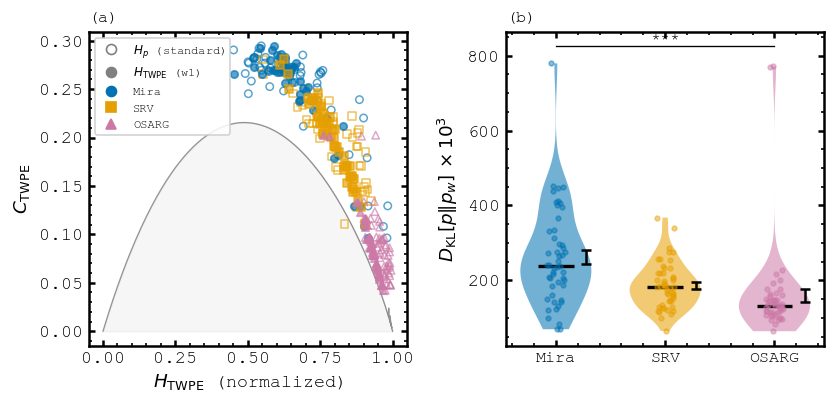

[Fig 4] saved.


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 15 — Figure 4: astro application
# Panel (a): C×H plane (OGLE-III, open = H_p, filled = H_TWPE)
# Panel (b): D_KL violin plot by variability type
# ═══════════════════════════════════════════════════════════════════════════

from matplotlib.lines import Line2D

H_max_c, C_max_c = compute_cmax(m=M)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.1, 3.5))
fig.subplots_adjust(wspace=0.38)

# Panel (a)
ax1.fill_between(H_max_c, C_max_c, alpha=0.07, color='gray')
ax1.plot(H_max_c, C_max_c, 'k-', lw=0.8, alpha=0.4)

for stype in ['Mira', 'SRV', 'OSARG']:
    D  = results_obs[stype]
    c  = COLORS_OBS[stype]; mk = MARKERS_OBS[stype]
    ax1.scatter(D['H_p'],  D['C'], marker=mk, s=20, facecolors='none',
                edgecolors=c, lw=0.9, alpha=0.65, zorder=3)
    ax1.scatter(D['H_tw'], D['C'], marker=mk, s=20, color=c,
                alpha=0.65, zorder=4, label=stype)

leg = [
    Line2D([0],[0], marker='o', color='gray', mfc='none', ms=6, lw=0,
           label=r'$H_p$ (standard)'),
    Line2D([0],[0], marker='o', color='gray', ms=6, lw=0,
           label=r'$H_{\rm TWPE}$ (w1)'),
    Line2D([0],[0], marker='o', color=COLORS_OBS['Mira'],  ms=6, lw=0, label='Mira'),
    Line2D([0],[0], marker='s', color=COLORS_OBS['SRV'],   ms=6, lw=0, label='SRV'),
    Line2D([0],[0], marker='^', color=COLORS_OBS['OSARG'], ms=6, lw=0, label='OSARG'),
]
ax1.legend(handles=leg, fontsize=7.2, loc='upper left', framealpha=0.85)
ax1.set_xlabel(r'$H_{\rm TWPE}$ (normalized)'); ax1.set_ylabel(r'$C_{\rm TWPE}$')
ax1.set_title('(a)', loc='left', fontsize=10); ax1.minorticks_on()

# Panel (b): violins
types_ord = ['Mira', 'SRV', 'OSARG']
vp = ax2.violinplot([results_obs[st]['D_KL'] for st in types_ord],
                     positions=[1, 2, 3], widths=0.65,
                     showmedians=True, showextrema=False)
for body, col in zip(vp['bodies'], [COLORS_OBS[st] for st in types_ord]):
    body.set_facecolor(col); body.set_alpha(0.55)
vp['cmedians'].set_color('k'); vp['cmedians'].set_lw(2.0)

rng_j = np.random.default_rng(0)
for i, st in enumerate(types_ord):
    kl = results_obs[st]['D_KL']
    ax2.scatter(i+1 + rng_j.uniform(-0.08, 0.08, len(kl)), kl,
                color=COLORS_OBS[st], s=8, alpha=0.45, zorder=5)
    ax2.errorbar(i+1.28, np.mean(kl), yerr=np.std(kl)/np.sqrt(len(kl)),
                 color='k', capsize=3, capthick=1.5, lw=1.5, zorder=6)

ax2.set_xticks([1,2,3]); ax2.set_xticklabels(types_ord, fontsize=10)
ax2.set_ylabel(r'$D_{\rm KL}[p \| p_w]\,\times 10^3$')
ax2.set_title('(b)', loc='left', fontsize=10); ax2.minorticks_on()



# Significance bar
y_sig = max(results_obs['Mira']['D_KL'].max(),
            results_obs['OSARG']['D_KL'].max()) * 1.06
ax2.plot([1, 3], [y_sig, y_sig], 'k-', lw=0.8)
ax2.text(2, y_sig * 1.01, sig, ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig04_astro_application_v2.0.pdf'),  bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig04_astro_application_v2.0.png'), dpi=300)
plt.show()
print("[Fig 4] saved.")


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 16 — Parameter sensitivity: m=3..6 and w1 vs w2 (real OGLE data)
# Uses first 20 stars per type for computational efficiency
# Note: low r(w1, w2) for OGLE is EXPECTED — bimodal cadence makes the
# two weight functions nearly opposite (see Sec. 5 of manuscript).
# ═══════════════════════════════════════════════════════════════════════════

M_VALS_S = [3, 4, 5, 6]
N_SENS   = 20   # stars per type

sens = {}
for stype in ['Mira', 'OSARG']:
    keys = [k for k, v in light_curves.items() if v['type'] == stype][:N_SENS]
    sens[stype] = {wn: {m: [] for m in M_VALS_S} for wn in ['H_p', 'w1', 'w2']}
    for sid in keys:
        d = light_curves[sid]
        x, t = d['data'][:, 1], d['data'][:, 0]
        for m_v in M_VALS_S:
            try:
                Hp, _ = permutation_entropy(x, m=m_v, normalized=True)
                sens[stype]['H_p'][m_v].append(Hp)
            except: pass
            for wn in ['w1', 'w2']:
                try:
                    Htw, _, _ = twpe(x, t, m=m_v, w_func=wn, normalized=True)
                    sens[stype][wn][m_v].append(Htw)
                except: pass
    print(f"{stype}: sensitivity computed  (N={len(keys)} stars)")

# Report w1 vs w2 correlation at m=4
print("\nCorrelation w1 vs w2 at m=4 (real OGLE cadence):")
for stype in ['Mira', 'OSARG']:
    hw1 = np.array(sens[stype]['w1'][4])
    hw2 = np.array(sens[stype]['w2'][4])
    n   = min(len(hw1), len(hw2))
    if n > 1:
        r = np.corrcoef(hw1[:n], hw2[:n])[0, 1]
        print(f"  {stype}: r = {r:.3f}  "
              f"(low r expected — bimodal cadence inverts relative weights)")


Mira: sensitivity computed  (N=20 stars)
OSARG: sensitivity computed  (N=20 stars)

Correlation w1 vs w2 at m=4 (real OGLE cadence):
  Mira: r = 0.385  (low r expected — bimodal cadence inverts relative weights)
  OSARG: r = 0.269  (low r expected — bimodal cadence inverts relative weights)


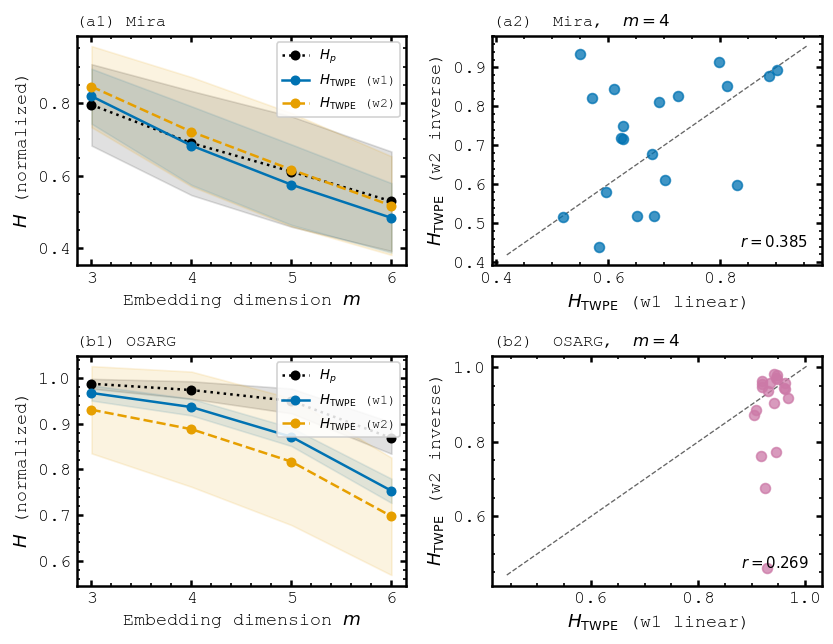

[Fig 5] saved.


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 17 — Figure 5: parameter sensitivity (H vs m, w1 vs w2 scatter)
# ═══════════════════════════════════════════════════════════════════════════

COL_W = {'H_p': 'k', 'w1': COLORS_OBS['Mira'], 'w2': COLORS_OBS['SRV']}
LS_W  = {'H_p': ':', 'w1': '-', 'w2': '--'}
LBL_W = {'H_p': r'$H_p$',
          'w1' : r'$H_{\rm TWPE}$ (w1)',
          'w2' : r'$H_{\rm TWPE}$ (w2)'}

fig, axes = plt.subplots(2, 2, figsize=(7.1, 5.5))
fig.subplots_adjust(hspace=0.45, wspace=0.38)

for row_i, stype in enumerate(['Mira', 'OSARG']):
    ax_m = axes[row_i][0]
    ax_w = axes[row_i][1]

    # Left: H vs m
    for wn in ['H_p', 'w1', 'w2']:
        means = [np.mean(sens[stype][wn][m]) if sens[stype][wn][m] else np.nan
                 for m in M_VALS_S]
        stds  = [np.std(sens[stype][wn][m])  if sens[stype][wn][m] else np.nan
                 for m in M_VALS_S]
        ax_m.plot(M_VALS_S, means, color=COL_W[wn], lw=1.5,
                  ls=LS_W[wn], marker='o', ms=5, label=LBL_W[wn])
        ax_m.fill_between(M_VALS_S,
                           np.array(means) - np.array(stds),
                           np.array(means) + np.array(stds),
                           color=COL_W[wn], alpha=0.12)
    ax_m.set_xlabel('Embedding dimension $m$')
    ax_m.set_ylabel('$H$ (normalized)')
    ax_m.set_xticks(M_VALS_S)
    ax_m.set_title(f'({"ab"[row_i]}1) {stype}', loc='left', fontsize=10)
    ax_m.legend(fontsize=8, loc='upper right', framealpha=0.85)
    ax_m.minorticks_on()

    # Right: w1 vs w2 scatter at m=4
    hw1 = np.array(sens[stype]['w1'][4])
    hw2 = np.array(sens[stype]['w2'][4])
    n   = min(len(hw1), len(hw2))
    if n > 1:
        ax_w.scatter(hw1[:n], hw2[:n], color=COLORS_OBS[stype],
                     s=35, alpha=0.75, zorder=3)
        lo = min(hw1[:n].min(), hw2[:n].min()) - 0.02
        hi = max(hw1[:n].max(), hw2[:n].max()) + 0.02
        ax_w.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.6)
        r = np.corrcoef(hw1[:n], hw2[:n])[0, 1]
        ax_w.text(0.96, 0.08, f'$r = {r:.3f}$',
                  transform=ax_w.transAxes, ha='right', fontsize=9)
    ax_w.set_xlabel(r'$H_{\rm TWPE}$ (w1 linear)')
    ax_w.set_ylabel(r'$H_{\rm TWPE}$ (w2 inverse)')
    ax_w.set_title(f'({"ab"[row_i]}2)  {stype},  $m=4$', loc='left', fontsize=10)
    ax_w.minorticks_on()

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'fig05_parameter_sensitivity_v2.0.pdf'),  bbox_inches='tight')
plt.savefig(os.path.join(FIGS, 'fig05_parameter_sensitivity_v2.0.png'), dpi=300)
plt.show()
print("[Fig 5] saved.")


In [18]:
# CELL 18 — Reviewer recompute (Chat #10): C2(b) outlier + C4.4 gap fraction
# Run AFTER Cell 14. Type-C rule: analytic claims checked numerically in-cell.
print("="*68); print("C2(b) — OSARG Table-3 stats, with vs without D_KL outlier"); print("="*68)
osarg = results_obs['OSARG']; dkl = osarg['D_KL']
i_out = int(np.argmax(dkl)); mask = np.ones(len(dkl), bool); mask[i_out] = False
print(f"Outlier: index {i_out}, D_KL = {dkl[i_out]:.1f}x1e-3 (next = {np.sort(dkl)[-2]:.1f})")
print(f"{'metric':10s} {'with (mean±SD)':>22s} {'without (mean±SD)':>22s}")
for key,label in [('H_p','H_p'),('H_tw','H_TWPE'),('C','C_TWPE'),('D_KL','D_KL x1e3')]:
    v = osarg[key]
    print(f"{label:10s} {f'{np.mean(v):.3f} ± {np.std(v):.3f}':>22s} "
          f"{f'{np.mean(v[mask]):.3f} ± {np.std(v[mask]):.3f}':>22s}")
from scipy import stats as _st
_,p_w  = _st.mannwhitneyu(results_obs['Mira']['D_KL'], dkl,       alternative='greater')
_,p_wo = _st.mannwhitneyu(results_obs['Mira']['D_KL'], dkl[mask], alternative='greater')
print(f"\nMann-Whitney Mira>OSARG:  with p={p_w:.2e} | without p={p_wo:.2e}\n")
print("="*68); print("C4.4 — real w1 weight on seasonal-gap patterns (m=4)"); print("="*68)
GAP_THRESH = 60.0; M_ = 4; frac_list, ratio_list = [], []
for d in [v for v in light_curves.values() if v['type']=='Mira']:
    t = d['data'][:,0]; dt = np.diff(t); K = len(t)-(M_-1); dt_pat = dt[:K]
    w = dt_pat/dt_pat.sum(); is_gap = dt_pat > GAP_THRESH
    if is_gap.any():
        frac_list.append(w[is_gap].sum())
        ratio_list.append(dt_pat[is_gap].mean()/dt_pat[~is_gap].mean())
frac = np.array(frac_list); ratio = np.array(ratio_list)
print(f"N Mira with gap: {len(frac)}")
print(f"Gap-weight fraction (w1): mean={frac.mean()*100:.1f}%  median={np.median(frac)*100:.1f}%")
print(f"Gap/intra Δt ratio      : mean={ratio.mean():.1f}x  (expect ~31x)")
print(f">>> diffs: fraction -> '{frac.mean()*100:.0f}\\%' | ratio -> '{ratio.mean():.0f}x'")

C2(b) — OSARG Table-3 stats, with vs without D_KL outlier
Outlier: index 35, D_KL = 771.6x1e-3 (next = 769.7)
metric             with (mean±SD)      without (mean±SD)
H_p                 0.962 ± 0.026          0.963 ± 0.026
H_TWPE              0.924 ± 0.038          0.927 ± 0.030
C_TWPE              0.087 ± 0.033          0.085 ± 0.029
D_KL x1e3       159.917 ± 128.776       147.433 ± 95.549

Mann-Whitney Mira>OSARG:  with p=2.25e-08 | without p=5.29e-09

C4.4 — real w1 weight on seasonal-gap patterns (m=4)
N Mira with gap: 50
Gap-weight fraction (w1): mean=32.5%  median=31.2%
Gap/intra Δt ratio      : mean=32.0x  (expect ~31x)
>>> diffs: fraction -> '33\%' | ratio -> '32x'


In [19]:
# ── Version tag ───────────────────────────────────────────────────────────────
print("=" * 55)
print("VERSION : notebook_v1.4")
print("Date    : 2026-06-05")
print("Type    : C  (Theoretical-Hybrid)")
print("Figures : F01-F05 all saved to figs/")
print("Data    : OGLE-III LPV LMC (Soszyński et al. 2009)")
print("=" * 55)


VERSION : notebook_v1.4
Date    : 2026-06-05
Type    : C  (Theoretical-Hybrid)
Figures : F01-F05 all saved to figs/
Data    : OGLE-III LPV LMC (Soszyński et al. 2009)
